In [1]:
import os 
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
from typing_extensions import TypedDict
class State(TypedDict):
    graph_info: str 

In [3]:
#First node in the graph

def start_play(state: State):
    print("Start_Playing node has been called")
    return {'graph_info': state['graph_info']+ 'I am planning to play.'}

In [4]:
def cricket(state: State):
    print("Cricket node has been called")
    return {'graph_info': state['graph_info']+ ' Cricket.'}

def badminton(state: State):
    print("Badminton node has been called")
    return {'graph_info': state['graph_info']+ ' Badminton.'}

In [5]:
import random
from typing import Literal #Literal is constant value, it can only take specific values

def random_play(state:State) -> Literal['play cricket', 'play badminton']:
    if random.random() > 0.5:
        return 'play cricket'
    else:
        return 'play badminton'

In [9]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END

graph = StateGraph(State)

#adding the nodes to the graph
graph.add_node("start playing", start_play)
graph.add_node("play cricket", cricket)
graph.add_node("play badminton", badminton)

#Schedule the flow with edges
graph.add_edge(START, "start playing")
graph.add_conditional_edges("start playing", random_play)
graph.add_edge("play cricket", END)
graph.add_edge("play badminton", END)

graph_builder = graph.compile()

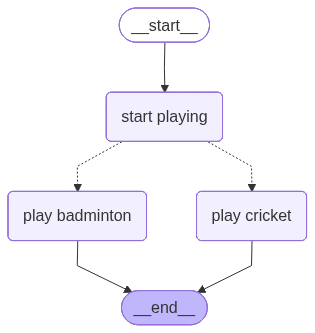

In [11]:
from IPython.display import Image, display
display(Image(graph_builder.get_graph().draw_mermaid_png()))